In [1]:
# Przeprowadzenie analizy oświetlenia - przykład do pracy
import cv2
import matplotlib.pyplot as plt

In [2]:
def lighting_analysis(image_nolight, image_light):
    # 1. Zmiana rozmiaru obrazów
    # [PARAMETR] - dodatkowo skuteczne może okazać się wycięcie fragmentu obrazu,
    # zamiast porównywania całości
    img_size = (256, 256)
    image_nolight = cv2.resize(image_nolight, img_size)
    image_light = cv2.resize(image_light, img_size)
    
    # 2. Konwersja obrazów do przestrzeni CIELUV
    image_nolight_luv = cv2.cvtColor(image_nolight, cv2.COLOR_BGR2Luv)
    image_light_luv = cv2.cvtColor(image_light, cv2.COLOR_BGR2Luv)
    
    # 3. Porównanie kanału L (Luminance) obu obrazów
    image_nolight_L = image_nolight_luv[:,:,0]
    image_light_L = image_light_luv[:,:,0]
    
    mean_diff_L = cv2.absdiff(image_nolight_L, image_light_L).mean()
    
    return mean_diff_L

In [3]:
# Przykładowe obrazy
image_nolight = cv2.imread("../../../Dane/Lighting/Spoof_daylight_nolight.png")
image_light = cv2.imread("../../../Dane/Lighting/Spoof_daylight_light.png")

print(lighting_analysis(image_nolight, image_light))

39.49383544921875


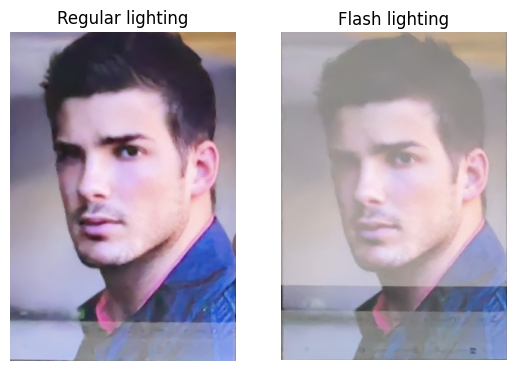

In [4]:
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(image_nolight, cv2.COLOR_BGR2RGB))
plt.title("Regular lighting")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(image_light, cv2.COLOR_BGR2RGB))
plt.title("Flash lighting")
plt.axis("off")

plt.show()